In [1]:
from torchmetrics.utilities.plot import plot_confusion_matrix

import custom_dataset as dataset
import helper_functions as hf
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch
from tqdm.auto import tqdm
from model import InVolcModel, DiceBCELoss

In [2]:
device = hf.set_device()
seed = 42
hf.set_seed(seed)


INFO:helper_functions:Semilla establecida a: 42


Using device: cpu


In [3]:
train_transforms = transforms.Compose([
    # transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    # transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [4]:
train_data = dataset.InVolcDataset(
    metadata_csv='metadata_sample_01.csv',
    transform=train_transforms,
    subset='train')
test_data = dataset.InVolcDataset(
    metadata_csv='metadata_sample_01.csv',
    transform=test_transforms,
    subset='test')

In [55]:
train_dataloader = DataLoader(
    train_data,
    batch_size=20,
    shuffle=True,
    num_workers=0
)
test_dataloader = DataLoader(
    test_data,
    batch_size=5,
    shuffle=False,
    num_workers=0
)

In [6]:
for batch in train_dataloader:
    data, masks, labels = hf.prepare_batch(
        batch,
        device=device,
        normalize_mask=True,
        require_float_labels=True
    )
    # solo el primer batch para debug
    break

In [7]:
loss_fn_clf = nn.BCEWithLogitsLoss()
loss_fn_seg = DiceBCELoss(bce_weight=0.7, dice_weight=0.3)

In [8]:
from metrics import MetricsManager

metrics = MetricsManager(device)

In [9]:
def train_step(model: torch.nn.Module,
               dataloader: DataLoader,
               loss_fn_clf: torch.nn.Module,
               loss_fn_seg: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device=device
               ):

    clf_losses, seg_losses = [], []
    model.train()
    loss = 0.0

    for idx, batch in enumerate(dataloader):

        images, masks, labels = hf.prepare_batch(
            batch, device=device,
            normalize_mask=True,
            require_float_labels=True
        )

        # forward pass
        clf_logits, seg_logits = model(images)

        # compute losses
        loss_clf = loss_fn_clf(clf_logits, labels.unsqueeze(1))
        loss_seg = loss_fn_seg(seg_logits, masks)

        loss = loss_clf + 2*loss_seg

        # backward pass and optimization
        optimizer.zero_grad()
        loss.backward()

        # opcional pero muy recomendable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        # logging
        clf_losses.append(loss_clf.item())
        seg_losses.append(loss_seg.item())

        # clf_probs = torch.sigmoid(clf_logits)        # (B,1)
        # clf_preds = (clf_probs > 0.5).float()
        #
        # seg_probs = torch.sigmoid(seg_logits)        # (B,1,H,W)
        # seg_preds = (seg_probs > 0.5).float()# (B,1)

    mean_clf = sum(clf_losses) / len(clf_losses)
    mean_seg = sum(seg_losses) / len(seg_losses)
    mean_tot = mean_clf + 2*mean_seg

    return mean_tot, mean_clf, mean_seg

In [10]:
def test_step(model,
              dataloader,
              loss_fn_clf,
              loss_fn_seg,
              device):

    model.eval()
    metrics.reset()
    clf_losses, seg_losses = [], []

    all_clf_preds = []
    all_clf_targets = []

    all_seg_preds = []
    all_seg_targets = []

    with torch.no_grad():
        for batch in dataloader:

            images, masks, labels = hf.prepare_batch(
                batch, device=device,
                normalize_mask=True,
                require_float_labels=True
            )

            # Forward
            clf_logits, seg_logits = model(images)

            # Losses
            loss_clf = loss_fn_clf(clf_logits, labels.unsqueeze(1))
            loss_seg = loss_fn_seg(seg_logits, masks)

            clf_losses.append(loss_clf.item())
            seg_losses.append(loss_seg.item())



            # Predictions
            clf_probs = torch.sigmoid(clf_logits)
            clf_preds = (clf_probs > 0.5).float()

            metrics.update(clf_preds.squeeze(1),labels)

            seg_probs = torch.sigmoid(seg_logits)
            seg_preds = (seg_probs > 0.5).float()

            # Save for computing metrics outside
            all_clf_preds.append(clf_preds.cpu())
            all_clf_targets.append(labels.cpu())

            all_seg_preds.append(seg_preds.cpu())
            all_seg_targets.append(masks.cpu())

    # Concatenate everything
    all_clf_preds = torch.cat(all_clf_preds)
    all_clf_targets = torch.cat(all_clf_targets)

    all_seg_preds = torch.cat(all_seg_preds)
    all_seg_targets = torch.cat(all_seg_targets)



    result = {
        "clf_loss": sum(clf_losses) / len(clf_losses),
        "seg_loss": sum(seg_losses) / len(seg_losses),
        "total_loss": sum(clf_losses) / len(clf_losses) + 2 * sum(seg_losses) / len(seg_losses),

        # Raw predictions → for computing metrics outside
        "clf_preds": all_clf_preds,
        "clf_targets": all_clf_targets,
        "seg_preds": all_seg_preds,
        "seg_targets": all_seg_targets,
    }

    return result

In [11]:
def train(model: torch.nn.Module,
          train_dataloader: DataLoader,
          test_dataloader: DataLoader,
          loss_fn_clf: torch.nn.Module,
          loss_fn_seg: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          num_epochs: int = 10,
          device: torch.device = device):

    test_results = []
    for epoch in tqdm(range(num_epochs)):
        train_total_loss, train_clf_loss, train_seg_loss = train_step(
            model,
            train_dataloader,
            loss_fn_clf,
            loss_fn_seg,
            optimizer,
            device
        )

        test_results_step = test_step(
            model,
            test_dataloader,
            loss_fn_clf,
            loss_fn_seg,
            device
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_total_loss:.4f} (Clf: {train_clf_loss:.4f}, Seg: {train_seg_loss:.4f})")
        print(f"  Test Loss: {test_results_step['total_loss']:.4f} (Clf: {test_results_step['clf_loss']:.4f}, Seg: {test_results_step['seg_loss']:.4f})")
        test_results.append(test_results_step)

    return test_results

In [27]:
hf.set_seed(seed)
invol_v1 = InVolcModel(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes_seg=1,
        num_classes_clf=1)
invol_v1.to(device)
optimizer = torch.optim.Adam(invol_v1.parameters(), lr=1e-4)
model1 = train(
    invol_v1,
    train_dataloader,
    test_dataloader,
    loss_fn_clf,
    loss_fn_seg,
    optimizer,
    num_epochs=30,
    device=device
)

INFO:helper_functions:Semilla establecida a: 42


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30
  Train Loss: 2.7067 (Clf: 0.6930, Seg: 1.0068)
  Test Loss: 3.3322 (Clf: 0.6018, Seg: 1.3652)
Epoch 2/30
  Train Loss: 2.3521 (Clf: 0.4569, Seg: 0.9476)
  Test Loss: 4.1470 (Clf: 0.4909, Seg: 1.8281)
Epoch 3/30
  Train Loss: 2.2561 (Clf: 0.4616, Seg: 0.8973)
  Test Loss: 3.4073 (Clf: 0.4371, Seg: 1.4851)
Epoch 4/30
  Train Loss: 2.0033 (Clf: 0.2583, Seg: 0.8725)
  Test Loss: 2.7796 (Clf: 0.3937, Seg: 1.1929)
Epoch 5/30
  Train Loss: 2.0612 (Clf: 0.3878, Seg: 0.8367)
  Test Loss: 2.3913 (Clf: 0.3775, Seg: 1.0069)
Epoch 6/30
  Train Loss: 1.8213 (Clf: 0.2103, Seg: 0.8055)
  Test Loss: 2.2377 (Clf: 0.3447, Seg: 0.9465)
Epoch 7/30
  Train Loss: 1.6810 (Clf: 0.1349, Seg: 0.7731)
  Test Loss: 1.8376 (Clf: 0.3474, Seg: 0.7451)
Epoch 8/30
  Train Loss: 1.6305 (Clf: 0.1314, Seg: 0.7496)
  Test Loss: 1.7231 (Clf: 0.3638, Seg: 0.6797)
Epoch 9/30
  Train Loss: 1.5335 (Clf: 0.0634, Seg: 0.7350)
  Test Loss: 1.6632 (Clf: 0.3603, Seg: 0.6515)
Epoch 10/30
  Train Loss: 1.5170 (Clf: 0.0889,

In [39]:
metrics.compute()

{'accuracy': 0.9375,
 'precision': 0.8888888955116272,
 'recall': 1.0,
 'f1_score': 0.9411764740943909,
 'auc': 0.9375}

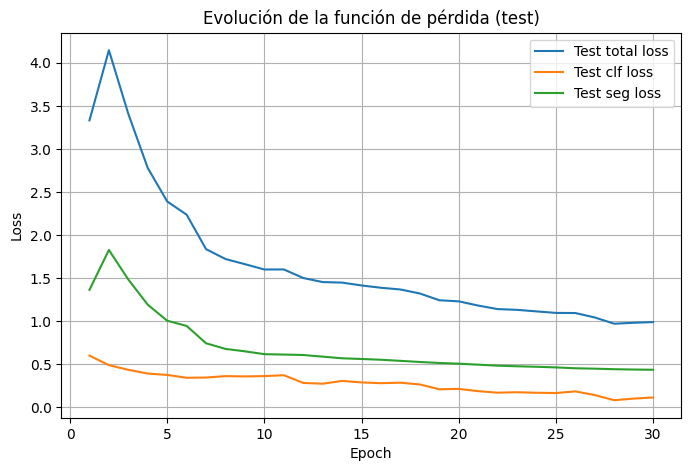

In [40]:
metrics.plot_result(model1)

In [48]:
def prediction(model: torch.nn.Module,
               dataloader: DataLoader,
               device: torch.device=device):

    model.eval()
    all_clf_preds = []
    all_seg_preds = []
    model.to(device)
    with torch.inference_mode():
        for batch in dataloader:

            images, _, _ = hf.prepare_batch(
                batch, device=device,
                normalize_mask=True,
                require_float_labels=False
            )

            # Forward
            clf_logits, seg_logits = model(images)

            # Predictions
            clf_probs = torch.sigmoid(clf_logits)
            clf_preds = (clf_probs > 0.5).float()

            seg_probs = torch.sigmoid(seg_logits)
            seg_preds = (seg_probs > 0.5).float()

            # Save for computing metrics outside
            all_clf_preds.append(clf_preds.cpu())
            all_seg_preds.append(seg_preds.cpu())

    # Concatenate everything
    all_clf_preds = torch.cat(all_clf_preds)
    all_seg_preds = torch.cat(all_seg_preds)

    result = {
        "clf_preds": all_clf_preds,
        "seg_preds": all_seg_preds,
    }

    return result

In [71]:
#seleccionar 5 elementos de forma aleatoria del test_dataloader
import random
hf.set_seed(seed)
random_indices = random.sample(range(len(test_data)), 5)
subset_sampler = torch.utils.data.SubsetRandomSampler(random_indices)
subset_dataloader = DataLoader(
    test_data,
    batch_size=5,
    sampler=subset_sampler,
    num_workers=0
)

predictions_mini = prediction(
    invol_v1,
    subset_dataloader,
    device=device
)


INFO:helper_functions:Semilla establecida a: 42


In [65]:
from torchmetrics.classification import BinaryConfusionMatrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_binary_confusion_matrix(clf_preds, clf_targets):
    """
    Genera y muestra la matriz de confusión binaria para clasificación de volcanes.
    """

    # Crear matriz de confusión
    confmat = BinaryConfusionMatrix()
    confusion_matrix = confmat(clf_preds.int(), clf_targets.int())

    # Convertir a numpy
    cm = confusion_matrix.numpy()

    # Plotear con seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='g',
        cmap='Blues',
        xticklabels=['No Volcano', 'Volcano'],
        yticklabels=['No Volcano', 'Volcano'],
        cbar_kws={'label': 'Count'}
    )

    plt.title('Confusion Matrix - Volcano Detection', fontsize=14, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Imprimir métricas adicionales
    tn, fp, fn, tp = cm.flatten()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nMétricas:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nMatriz de Confusión:")
    print(f"TN: {tn}, FP: {fp}")
    print(f"FN: {fn}, TP: {tp}")

    return confusion_matrix


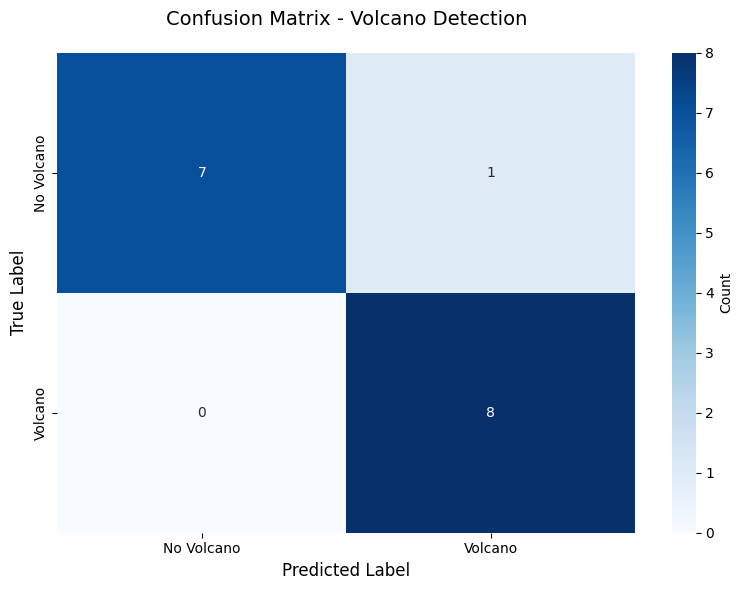


Métricas:
Accuracy: 0.9375
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412

Matriz de Confusión:
TN: 7, FP: 1
FN: 0, TP: 8


tensor([[7, 1],
        [0, 8]])

In [66]:
all_predictions = prediction(
    invol_v1,
    test_dataloader,
    device=device
)

clf_preds = all_predictions['clf_preds']
clf_preds = clf_preds.squeeze(1)
clf_targets = []
for batch in test_dataloader:
    _, _, labels = hf.prepare_batch(
        batch,
        device=device,
        normalize_mask=True,
        require_float_labels=True
    )
    clf_targets.append(labels.cpu())
clf_targets = torch.cat(clf_targets)
plot_binary_confusion_matrix(clf_preds, clf_targets)




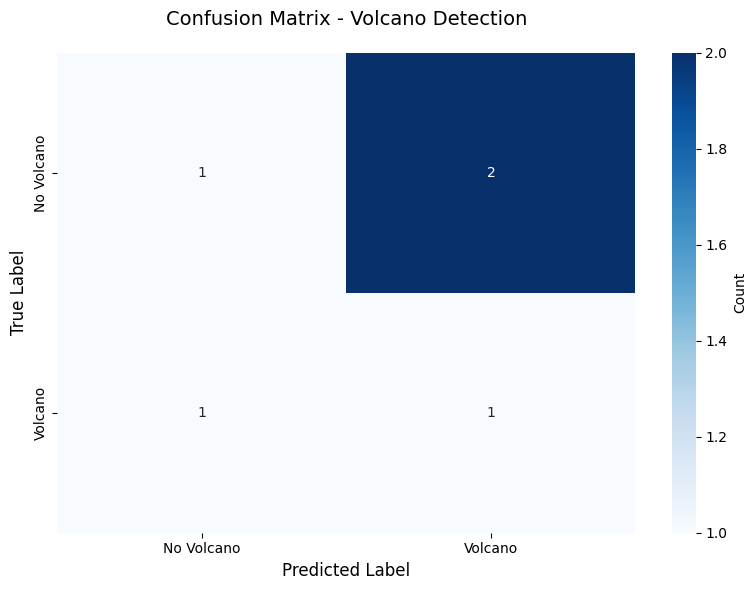


Métricas:
Accuracy: 0.4000
Precision: 0.3333
Recall: 0.5000
F1-Score: 0.4000

Matriz de Confusión:
TN: 1, FP: 2
FN: 1, TP: 1


tensor([[1, 2],
        [1, 1]])

In [72]:
clf_preds = predictions['clf_preds']
clf_preds = clf_preds.squeeze(1)
clf_targets = []
for batch in subset_dataloader:
    _, _, labels = hf.prepare_batch(
        batch,
        device=device,
        normalize_mask=True,
        require_float_labels=True
    )
    clf_targets.append(labels.cpu())
clf_targets = torch.cat(clf_targets)
plot_binary_confusion_matrix(clf_preds, clf_targets)

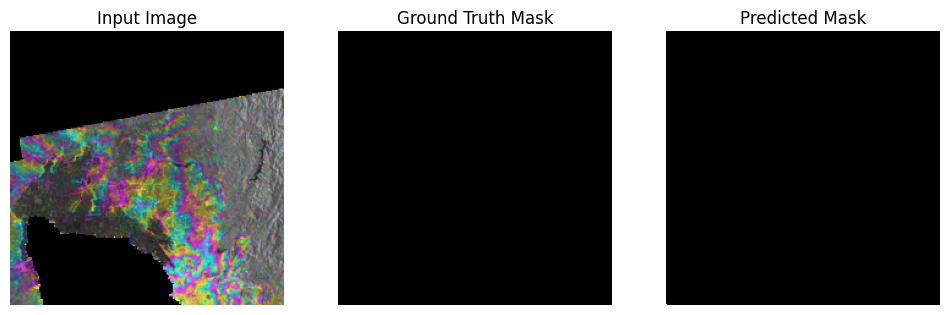

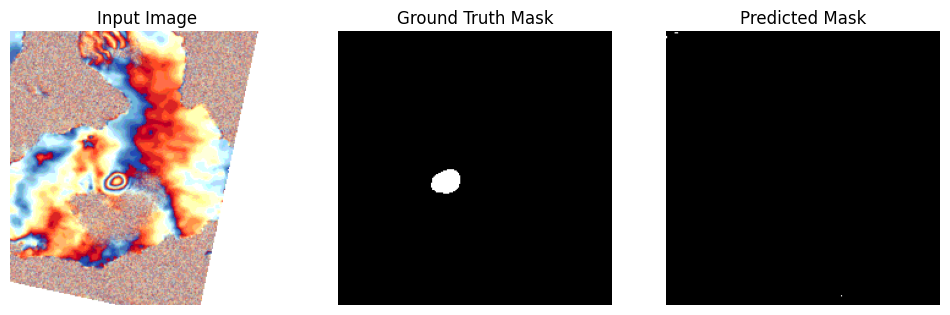

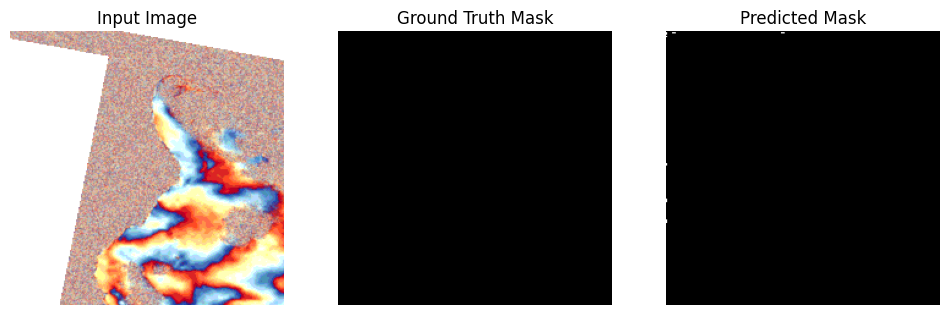

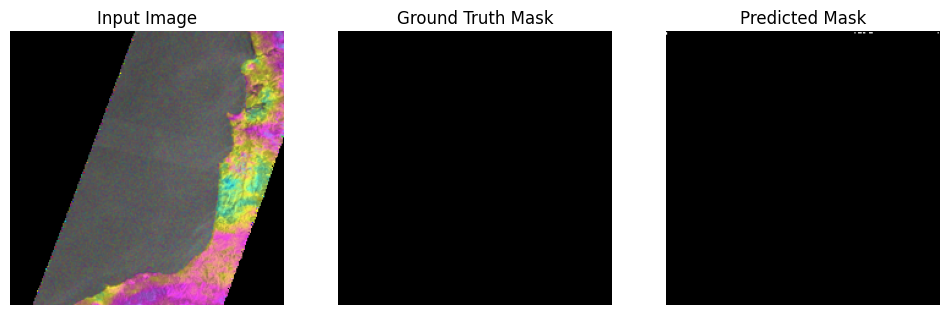

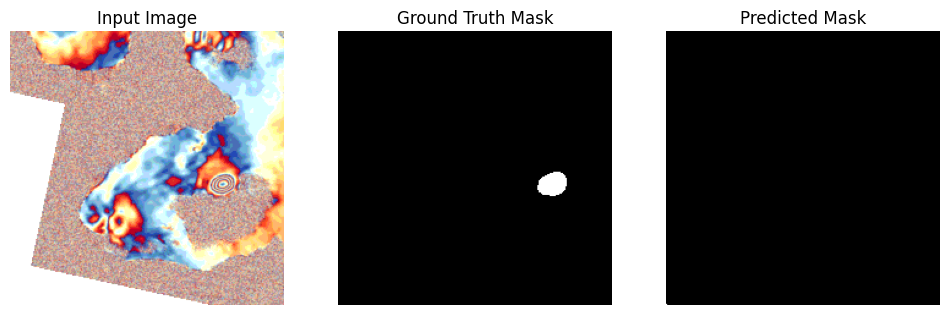

In [43]:
hf.plot_segmentation_results(subset_dataloader, predictions)

In [44]:
clf_preds = predictions['clf_preds']
for i, pred in enumerate(clf_preds):
    print(f"Image {i+1}: Volcano Presence Prediction: {'Yes' if pred.item() == 1.0 else 'No'}")

Image 1: Volcano Presence Prediction: No
Image 2: Volcano Presence Prediction: Yes
Image 3: Volcano Presence Prediction: Yes
Image 4: Volcano Presence Prediction: Yes
Image 5: Volcano Presence Prediction: No
